In [52]:
import numpy as np
import pandas as pd
import yfinance as yf
from scipy.interpolate import make_interp_spline
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Preprocessing

In [53]:
ticker = "AAPL"
df = yf.download(ticker, start = "2010-01-04", end = "2022-12-03")
df.head(10)

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2010-01-04,6.406479,6.421147,6.357684,6.389116,493729600
2010-01-05,6.417558,6.453780,6.383730,6.424144,601904800
2010-01-06,6.315477,6.443002,6.308891,6.417557,552160000
2010-01-07,6.303802,6.346311,6.258001,6.338827,477131200
2010-01-08,6.345711,6.346310,6.258300,6.295419,447610800
2010-01-11,6.289733,6.376246,6.240040,6.370259,462229600
2010-01-12,6.218186,6.279554,6.179270,6.262191,594459600
2010-01-13,6.305897,6.314279,6.109821,6.222678,605892000


In [54]:
df = df.reindex(pd.date_range(start = df.index.min(), end = df.index.max(), freq = 'D'))
df.head(10)

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
2010-01-04,6.406479,6.421147,6.357684,6.389116,493729600.0
2010-01-05,6.417558,6.453780,6.383730,6.424144,601904800.0
2010-01-06,6.315477,6.443002,6.308891,6.417557,552160000.0
2010-01-07,6.303802,6.346311,6.258001,6.338827,477131200.0
2010-01-08,6.345711,6.346310,6.258300,6.295419,447610800.0
2010-01-09,NaN,NaN,NaN,NaN,NaN
2010-01-10,NaN,NaN,NaN,NaN,NaN
2010-01-11,6.289733,6.376246,6.240040,6.370259,462229600.0
2010-01-12,6.218186,6.279554,6.179270,6.262191,594459600.0


In [55]:
df2 = pd.DataFrame({})

df2['close'] = df['Close']
df2['high'] = df['High']
df2['low'] = df['Low']
df2['open'] = df['Open']
df2['volume'] = df['Volume']


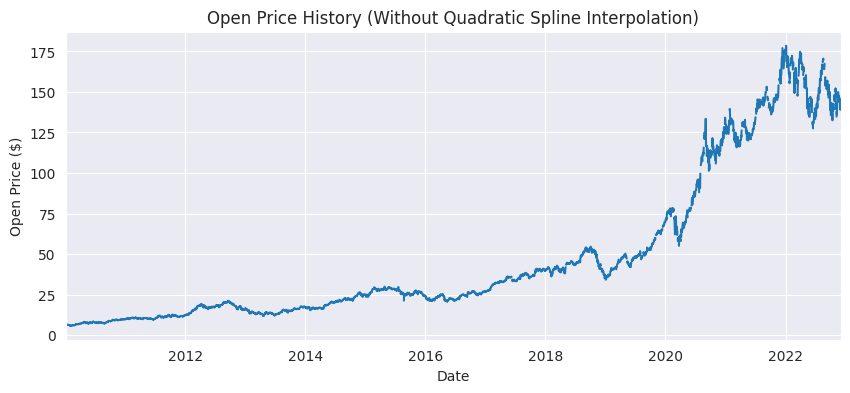

In [56]:
plt.figure(figsize = (10, 4))
sns.set_style("darkgrid")
df2['open'].plot(kind = "line")
plt.title("Open Price History (Without Quadratic Spline Interpolation)")
plt.xlabel("Date")
plt.ylabel("Open Price ($)")
plt.show()

In [57]:
df2.isna().sum()

,0
close,1463
high,1463
low,1463
open,1463
volume,1463


In [58]:
close_series_with_gaps = df2['close']

# Quadratic Spline Interpolation

In [59]:
all_idx = np.arange(len(close_series_with_gaps))

In [60]:
valid_mask = ~close_series_with_gaps.isna()
valid_idx = all_idx[valid_mask]
valid_values = close_series_with_gaps[valid_mask]

In [61]:
quadratic_spline_function = make_interp_spline(valid_idx, valid_values, k = 2)

In [62]:
interpolated_values = quadratic_spline_function(all_idx)

In [63]:
clean_close_series = pd.Series(interpolated_values, index = close_series_with_gaps.index)

In [64]:
clean_close_series.head(5)

,0
2010-01-04,6.406479
2010-01-05,6.417558
2010-01-06,6.315477
2010-01-07,6.303802
2010-01-08,6.345711


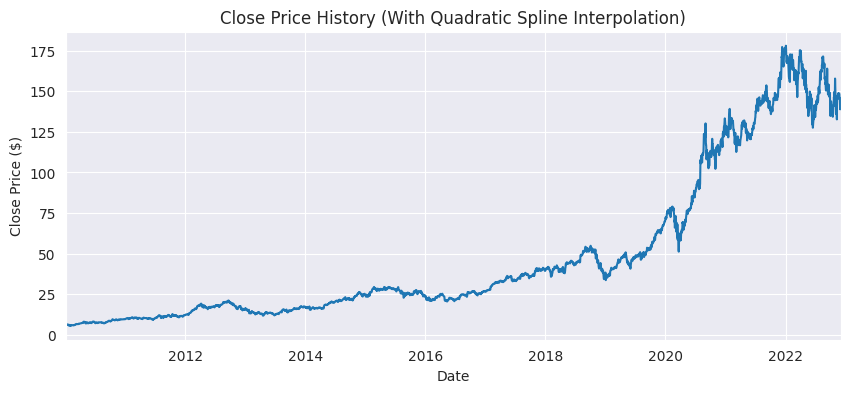

In [65]:
plt.figure(figsize = (10, 4))
sns.set_style("darkgrid")
clean_close_series.plot(kind = "line")
plt.title("Close Price History (With Quadratic Spline Interpolation)")
plt.xlabel("Date")
plt.ylabel("Close Price ($)")
plt.show()

# Train-Test-Split

In [66]:
split_idx = int(len(clean_close_series) * 0.8)
train_series = clean_close_series[:split_idx]
test_series = clean_close_series[split_idx:]

# Stationarity Test

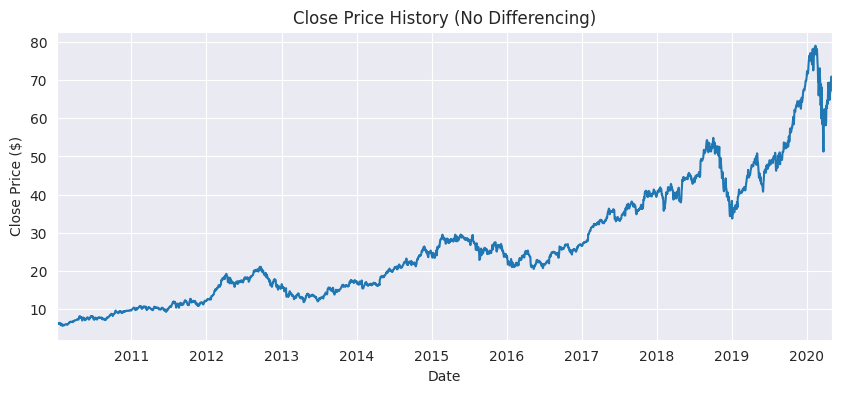

In [67]:
plt.figure(figsize = (10, 4))
sns.set_style("darkgrid")
train_series.plot(kind = "line")
plt.title("Close Price History (No Differencing)")
plt.xlabel("Date")
plt.ylabel("Close Price ($)")
plt.show()

In [68]:
result = adfuller(train_series)
print("ADF Statistic: %f" % result[0])
print("p-value: %f" % result[1])

ADF Statistic: 0.160183
p-value: 0.969938


In [69]:
close_series_diff = train_series.diff().dropna()

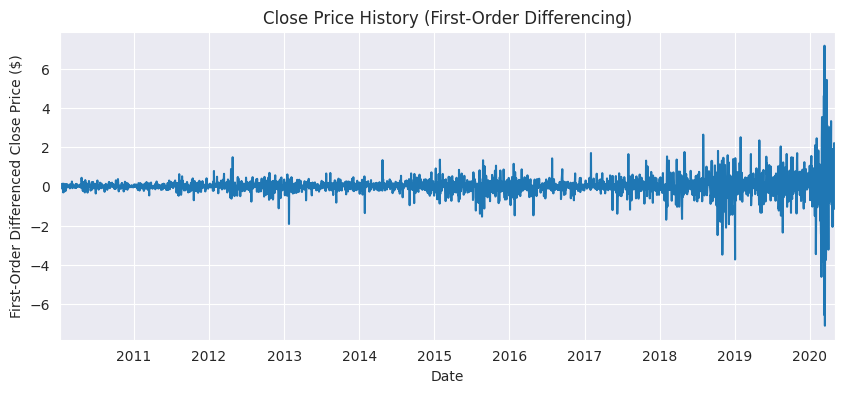

In [70]:
plt.figure(figsize = (10, 4))
sns.set_style("darkgrid")
close_series_diff.plot(kind = "line")
plt.title("Close Price History (First-Order Differencing)")
plt.xlabel("Date")
plt.ylabel("First-Order Differenced Close Price ($)")
plt.show()

In [71]:
result1 = adfuller(close_series_diff)
print("ADF Statistic: %f" % result1[0])
print("p-value: %f" % result1[1])

ADF Statistic: -9.568474
p-value: 0.000000


# Model Training - ARIMA

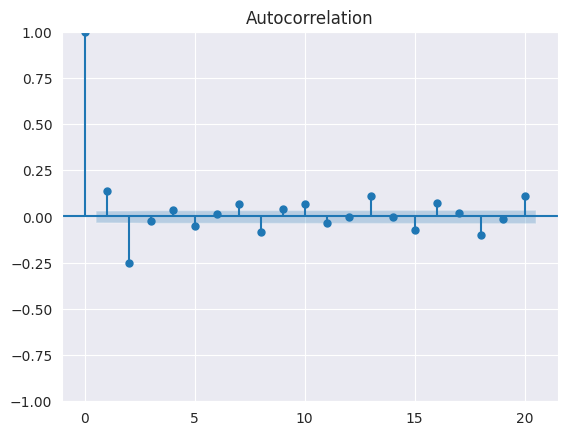

In [72]:
plot_acf(close_series_diff, lags = 20)
plt.show()

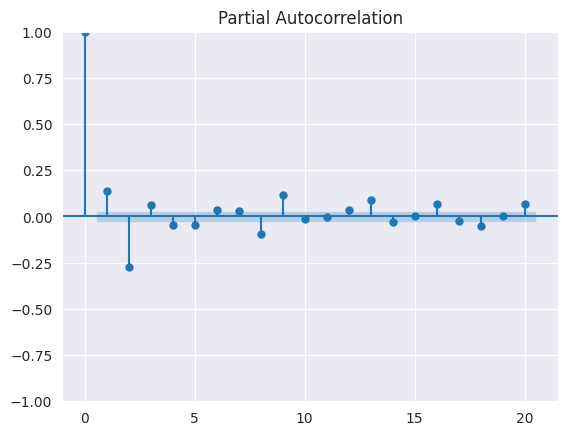

In [73]:
plot_pacf(close_series_diff, lags = 20)
plt.show()

In [74]:
model = ARIMA(train_series, order = (2, 1, 3))
model_fitted = model.fit()

print(model_fitted.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 3772
Model:                 ARIMA(2, 1, 3)   Log Likelihood               -2624.939
Date:                Sun, 07 Jun 2026   AIC                           5261.877
Time:                        14:11:37   BIC                           5299.288
Sample:                    01-04-2010   HQIC                          5275.178
                         - 05-02-2020                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5746      0.018    -32.409      0.000      -0.609      -0.540
ar.L2         -0.5781      0.011    -51.673      0.000      -0.600      -0.556
ma.L1          0.7735      0.020     38.379      0.0

# Model Evaluation

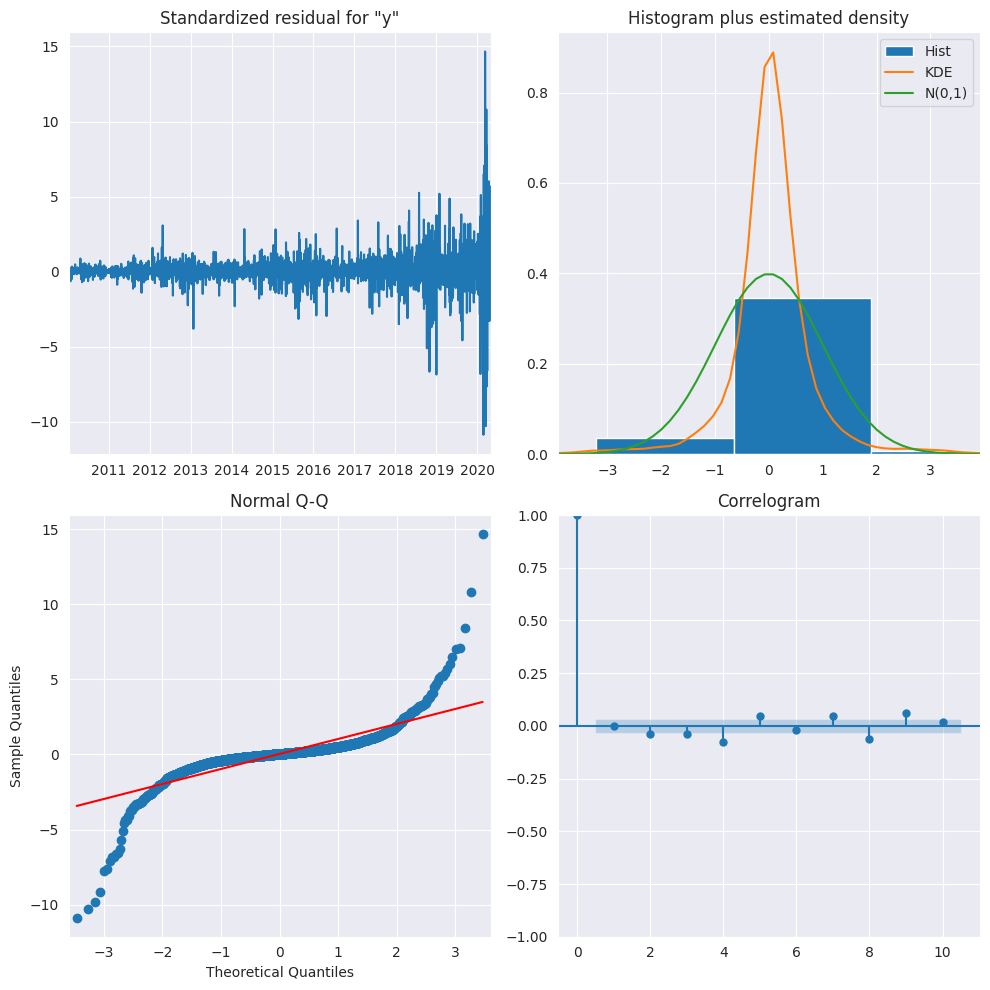

In [75]:
model_fitted.plot_diagnostics(figsize = (10, 10))
plt.tight_layout()
plt.show()

In [76]:
lb_results = acorr_ljungbox(model_fitted.resid,
                            lags = list(range(1, 21)),
                            return_df = True)
print(lb_results)

       lb_stat     lb_pvalue
1     0.000787  9.776181e-01
2     5.403030  6.710378e-02
3    11.053892  1.143800e-02
4    31.167168  2.830179e-06
5    38.382013  3.161883e-07
6    39.517547  5.665701e-07
7    46.545014  6.846798e-08
8    59.508014  5.820468e-10
9    72.225700  5.565372e-12
10   73.281465  1.026728e-11
11   73.482056  2.647793e-11
12   73.777206  6.252130e-11
13   89.978892  1.410595e-13
14   91.051048  2.401678e-13
15   99.382253  1.708226e-14
16  107.658970  1.247506e-15
17  107.726314  3.226256e-15
18  118.584657  7.759243e-17
19  121.103428  6.895634e-17
20  156.001808  4.428143e-23


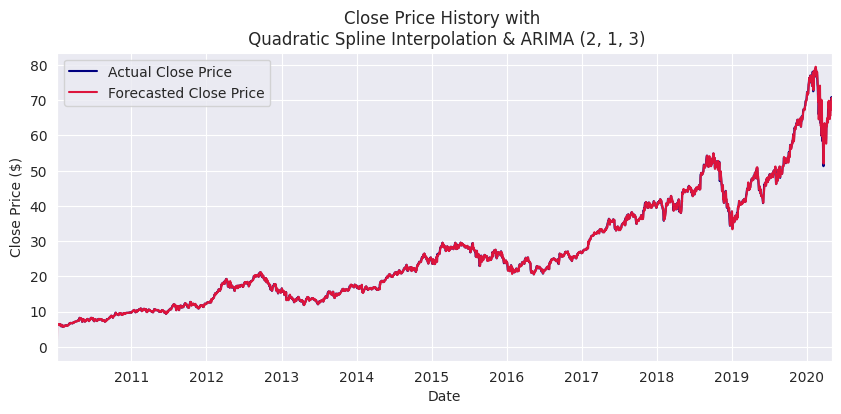

In [77]:
plt.figure(figsize = (10, 4))
forecast_train = model_fitted.predict(train_series.index[0], train_series.index[-1])
train_series.plot(kind = "line", color = "navy", label = "Actual Close Price")
forecast_train.plot(kind = "line", color = "crimson", label = "Forecasted Close Price")
plt.title("Close Price History with \n Quadratic Spline Interpolation & ARIMA (2, 1, 3)")
plt.xlabel("Date")
plt.ylabel("Close Price ($)")
plt.legend()
plt.show()

# Rolling Forecast

In [78]:
history = [x for x in train_series]
predictions = list()

model_f = ARIMA(history, order = (2, 1, 3))
model_fitted_f = model_f.fit()

for i in range(len(test_series)):
  obs = test_series[i]
  model_fitted_f = model_fitted_f.append([obs], refit = False)
  output = model_fitted_f.forecast()
  yhat = output[0]
  predictions.append(yhat)
  history.append(obs)

  print("Progress: {}/{} | Predicted: {:.2f}, Actual: {:.2f}".format(i,len(test_series), yhat, obs))


Progress: 0/944 | Predicted: 69.90, Actual: 69.85
Progress: 1/944 | Predicted: 70.64, Actual: 70.77
Progress: 2/944 | Predicted: 72.03, Actual: 71.83
Progress: 3/944 | Predicted: 72.51, Actual: 72.57
Progress: 4/944 | Predicted: 73.33, Actual: 73.32
Progress: 5/944 | Predicted: 75.36, Actual: 75.07
Progress: 6/944 | Predicted: 76.06, Actual: 76.23
Progress: 7/944 | Predicted: 76.47, Actual: 76.56
Progress: 8/944 | Predicted: 76.29, Actual: 76.25
Progress: 9/944 | Predicted: 75.23, Actual: 75.38
Progress: 10/944 | Predicted: 74.47, Actual: 74.47
Progress: 11/944 | Predicted: 75.19, Actual: 74.93
Progress: 12/944 | Predicted: 74.16, Actual: 74.48
Progress: 13/944 | Predicted: 75.04, Actual: 74.82
Progress: 14/944 | Predicted: 76.21, Actual: 76.01
Progress: 15/944 | Predicted: 75.90, Actual: 76.24
Progress: 16/944 | Predicted: 75.83, Actual: 75.80
Progress: 17/944 | Predicted: 77.74, Actual: 77.27
Progress: 18/944 | Predicted: 76.07, Actual: 76.70
Progress: 19/944 | Predicted: 77.57, Actu

In [79]:
print("MAE: {:.4f}".format(mean_absolute_error(test_series, predictions)))
print("RMSE: {:.4f}".format(np.sqrt(mean_squared_error(test_series, predictions))))
print("R2: {:.4f}".format(r2_score(test_series, predictions)))

MAE: 0.4772
RMSE: 0.6926
R2: 0.9992


In [80]:
predictions_df = pd.Series(predictions, index = test_series.index)

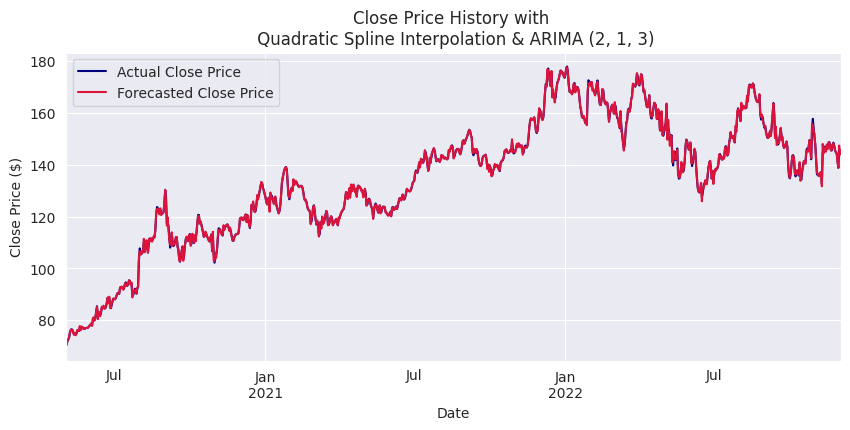

In [81]:
plt.figure(figsize = (10, 4))
test_series.plot(kind = "line", color = "navy", label = "Actual Close Price")
predictions_df.plot(kind = "line", color = "crimson", label = "Forecasted Close Price")
plt.title("Close Price History with \n Quadratic Spline Interpolation & ARIMA (2, 1, 3)")
plt.xlabel("Date")
plt.ylabel("Close Price ($)")
plt.legend()
plt.show()